In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("../01_data/02_processed/cleaned_data.csv")

In [2]:
#1. How many customers defaulted vs did not default?
counts = df["default.payment.next.month"].value_counts()

percentages = df["default.payment.next.month"].value_counts(normalize=True) * 100

print(counts)
print(percentages)

default.payment.next.month
0    23364
1     6636
Name: count, dtype: int64
default.payment.next.month
0    77.88
1    22.12
Name: proportion, dtype: float64


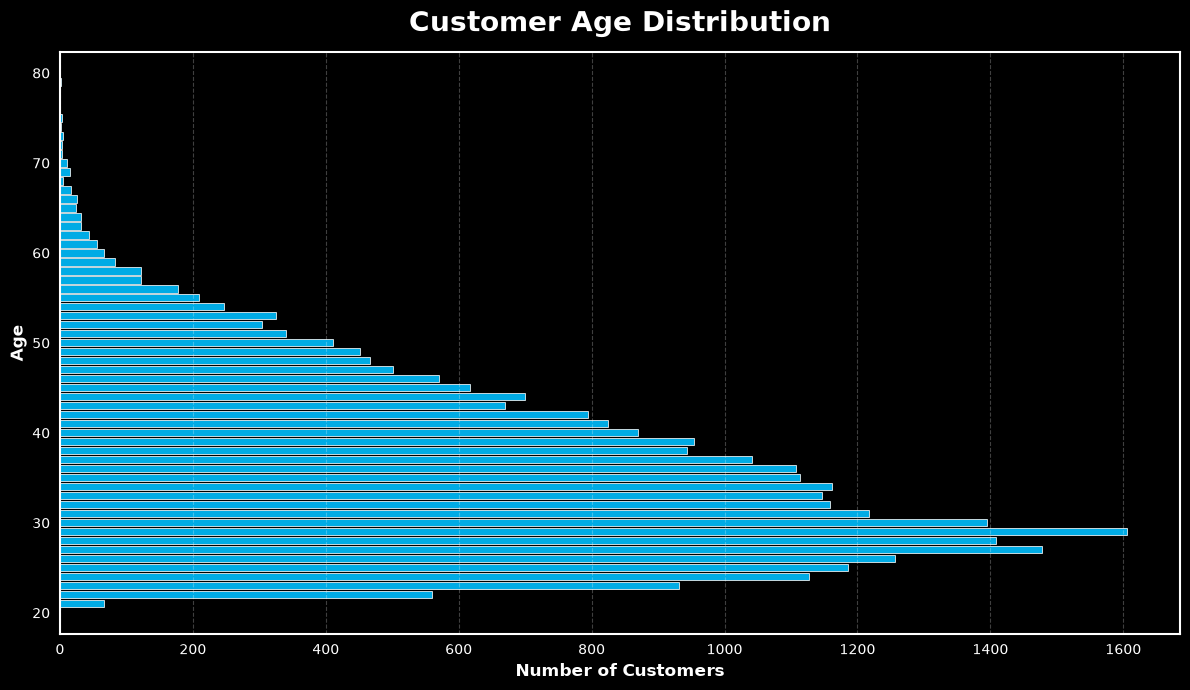

In [3]:
import matplotlib.pyplot as plt
import pandas as pd

Age = df["AGE"].value_counts().sort_index()

plt.figure(figsize=(12, 7), facecolor="black")
ax = plt.gca()
ax.set_facecolor("black")

bars = plt.barh(
    Age.index,
    Age.values,
    color="#00BFFF",
    edgecolor="white",
    linewidth=0.6,
    alpha=0.9
)



# Title
plt.title(
    "Customer Age Distribution",
    fontsize=20,
    fontweight="bold",
    color="white",
    pad=15
)

# Labels
plt.xlabel(
    "Number of Customers",
    fontsize=12,
    fontweight="bold",
    color="white"
)

plt.ylabel(
    "Age",
    fontsize=12,
    fontweight="bold",
    color="white"
)

# Tick colors
plt.xticks(color="white")
plt.yticks(color="white")

# Grid
plt.grid(
    axis="x",
    linestyle="--",
    alpha=0.25,
    color="white"
)

# ⭐ Complete frame outline
for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_color("white")
    spine.set_linewidth(1.5)

plt.tight_layout()
plt.show()

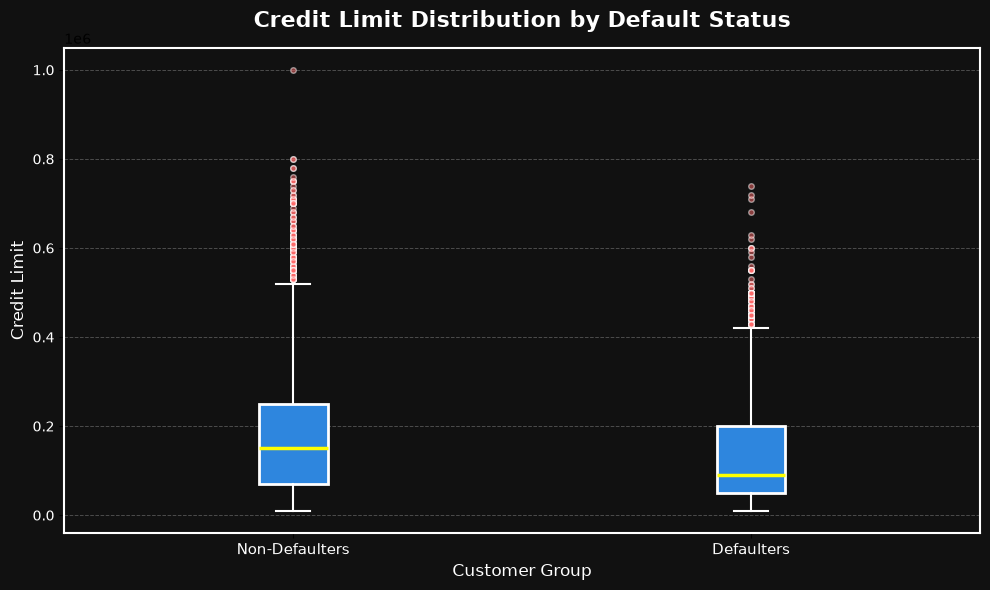

In [4]:
import matplotlib.pyplot as plt

# Separate the two groups
non_default = df[df["default.payment.next.month"] == 0]["LIMIT_BAL"]
default = df[df["default.payment.next.month"] == 1]["LIMIT_BAL"]

plt.figure(figsize=(10, 6))

plt.boxplot(
    [non_default, default],
    tick_labels=["Non-Defaulters", "Defaulters"],
    patch_artist=True,
    boxprops=dict(
        facecolor="#2E86DE",
        edgecolor="white",
        linewidth=2
    ),
    medianprops=dict(
        color="yellow",
        linewidth=2.5
    ),
    whiskerprops=dict(
        color="white",
        linewidth=1.5
    ),
    capprops=dict(
        color="white",
        linewidth=1.5
    ),
    flierprops=dict(
        marker="o",
        markerfacecolor="#FF6B6B",
        markeredgecolor="white",
        markersize=4,
        alpha=0.5
    )
)

# Dark background
ax = plt.gca()
ax.set_facecolor("#111111")
plt.gcf().patch.set_facecolor("#111111")

# Title
plt.title(
    "Credit Limit Distribution by Default Status",
    fontsize=16,
    fontweight="bold",
    color="white",
    pad=15
)

# Labels
plt.xlabel("Customer Group", fontsize=12, color="white")
plt.ylabel("Credit Limit", fontsize=12, color="white")

# Tick colors
plt.xticks(color="white", fontsize=11)
plt.yticks(color="white")

# Frame / outline
for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_color("white")
    spine.set_linewidth(1.5)

# Grid
plt.grid(
    axis="y",
    linestyle="--",
    linewidth=0.7,
    alpha=0.25,
    color="white"
)

plt.tight_layout()
plt.show()

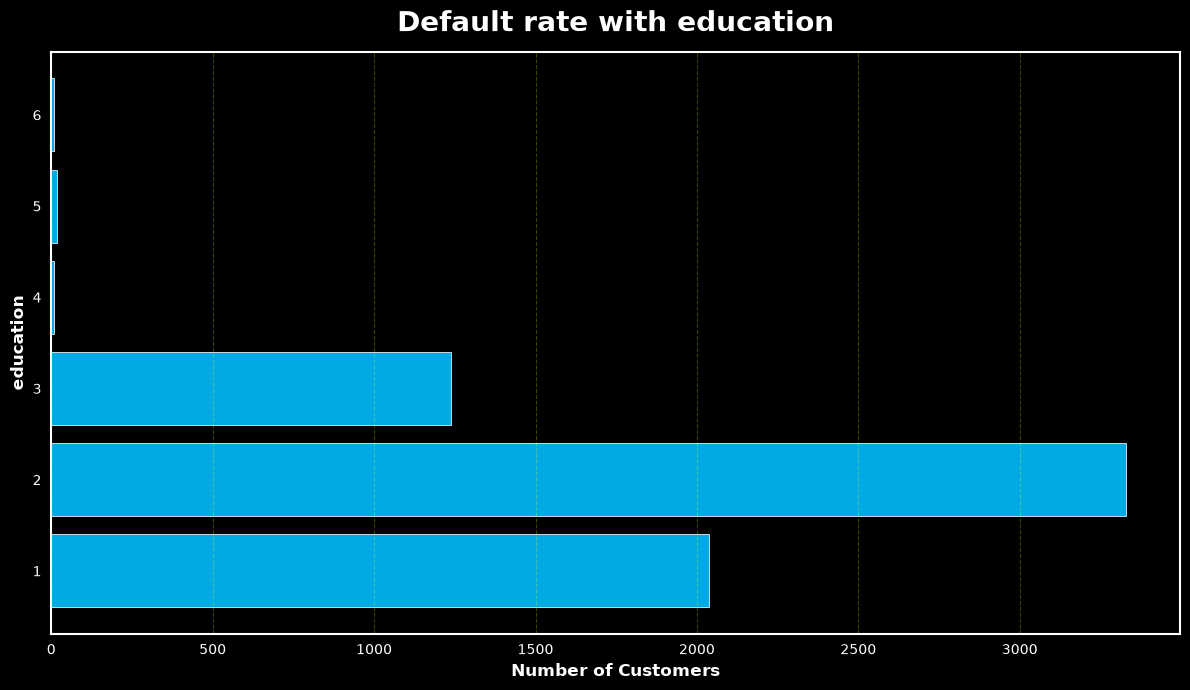

In [5]:
#How does default rate vary with education level?
import matplotlib.pyplot as plt
import pandas as pd
education = df[df["default.payment.next.month"] == 1]["EDUCATION"].value_counts().sort_values()
plt.figure(figsize=(12, 7), facecolor="black")
ax = plt.gca()
ax.set_facecolor("black")

bars = plt.barh(
    education.index,
    education.values,
    color="#00BFFF",
    edgecolor="white",
    linewidth=0.6,
    alpha=0.9
)



# Title
plt.title(
    "Default rate with education",
    fontsize=20,
    fontweight="bold",
    color="white",
    pad=15
)

# Labels
plt.xlabel(
    "Number of Customers",
    fontsize=12,
    fontweight="bold",
    color="white"
)

plt.ylabel(
    "education",
    fontsize=12,
    fontweight="bold",
    color="white"
)

# Tick colors
plt.xticks(color="white")
plt.yticks(color="white")

# Grid
plt.grid(
    axis="x",
    linestyle="--",
    alpha=0.25,
    color="yellow"
)
for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_color("white")
    spine.set_linewidth(1.5)

plt.tight_layout()
plt.show()


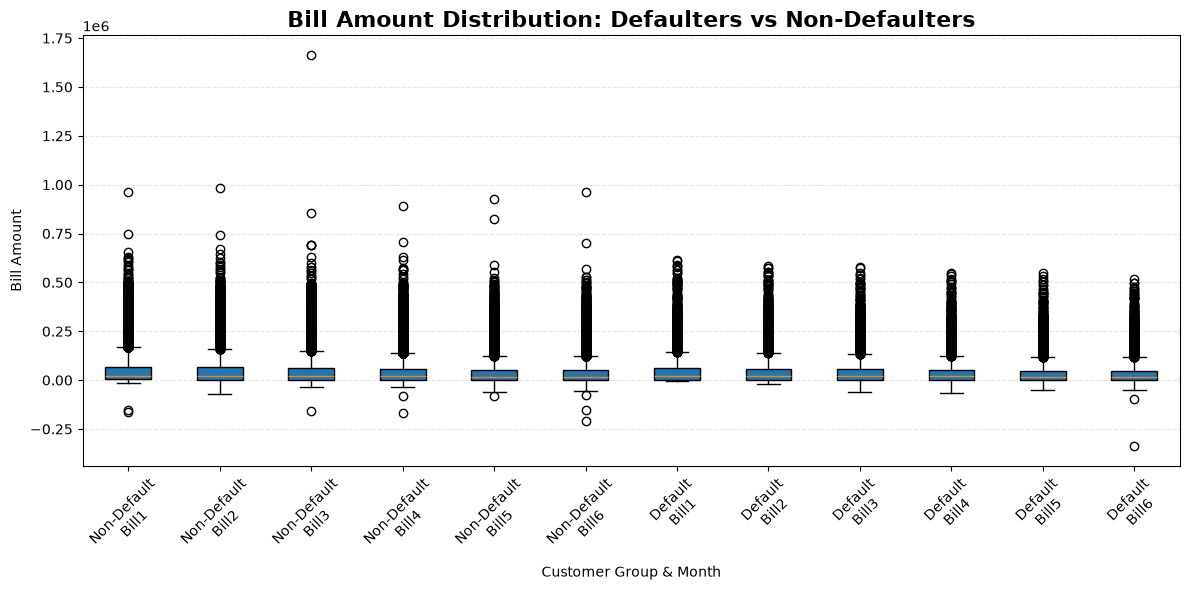

In [6]:
#How do bill amounts and previous payment amounts differ between defaulters and non-defaulters?
import matplotlib.pyplot as plt

bill_cols = [
    "BILL_AMT1",
    "BILL_AMT2",
    "BILL_AMT3",
    "BILL_AMT4",
    "BILL_AMT5",
    "BILL_AMT6"
]

bill_data = [
    df[df["default.payment.next.month"] == 0][col]
    for col in bill_cols
] + [
    df[df["default.payment.next.month"] == 1][col]
    for col in bill_cols
]

plt.figure(figsize=(12, 6))

plt.boxplot(
    bill_data,
    tick_labels=[
        "Non-Default\nBill1", "Non-Default\nBill2", "Non-Default\nBill3",
        "Non-Default\nBill4", "Non-Default\nBill5", "Non-Default\nBill6",
        "Default\nBill1", "Default\nBill2", "Default\nBill3",
        "Default\nBill4", "Default\nBill5", "Default\nBill6"
    ],
    patch_artist=True
)

plt.title(
    "Bill Amount Distribution: Defaulters vs Non-Defaulters",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Customer Group & Month")
plt.ylabel("Bill Amount")

plt.xticks(rotation=45)
plt.grid(axis="y", linestyle="--", alpha=0.3)

plt.tight_layout()
plt.show()

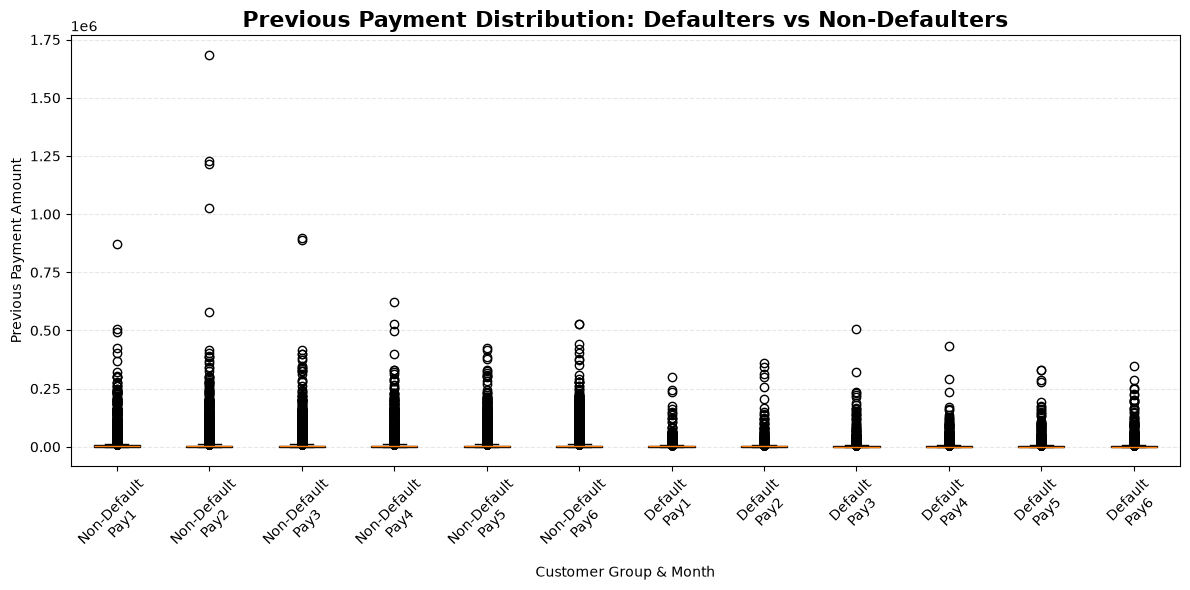

In [7]:
payment_cols = [
    "PAY_AMT1",
    "PAY_AMT2",
    "PAY_AMT3",
    "PAY_AMT4",
    "PAY_AMT5",
    "PAY_AMT6"
]

payment_data = [
    df[df["default.payment.next.month"] == 0][col]
    for col in payment_cols
] + [
    df[df["default.payment.next.month"] == 1][col]
    for col in payment_cols
]

plt.figure(figsize=(12, 6))

plt.boxplot(
    payment_data,
    tick_labels=[
        "Non-Default\nPay1", "Non-Default\nPay2", "Non-Default\nPay3",
        "Non-Default\nPay4", "Non-Default\nPay5", "Non-Default\nPay6",
        "Default\nPay1", "Default\nPay2", "Default\nPay3",
        "Default\nPay4", "Default\nPay5", "Default\nPay6"
    ],
    patch_artist=True
)

plt.title(
    "Previous Payment Distribution: Defaulters vs Non-Defaulters",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Customer Group & Month")
plt.ylabel("Previous Payment Amount")

plt.xticks(rotation=45)
plt.grid(axis="y", linestyle="--", alpha=0.3)

plt.tight_layout()
plt.show()